# 🏢 Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

**ПЛАН**
- оценю данные
- сделаю предобработку данных
- проведу исследовательский анализ
- сделаю вывод

## Загрузка и первичиный анализ данных 📥

   total_images  last_price  total_area first_day_exposition  rooms  \
0            20  13000000.0       108.0  2019-03-07T00:00:00      3   
1             7   3350000.0        40.4  2018-12-04T00:00:00      1   
2            10   5196000.0        56.0  2015-08-20T00:00:00      2   
3             0  64900000.0       159.0  2015-07-24T00:00:00      3   
4             2  10000000.0       100.0  2018-06-19T00:00:00      2   

   ceiling_height  floors_total  living_area  floor is_apartment  ...  \
0            2.70          16.0         51.0      8          NaN  ...   
1             NaN          11.0         18.6      1          NaN  ...   
2             NaN           5.0         34.3      4          NaN  ...   
3             NaN          14.0          NaN      9          NaN  ...   
4            3.03          14.0         32.0     13          NaN  ...   

   kitchen_area  balcony    locality_name  airports_nearest  \
0          25.0      NaN  Санкт-Петербург           18863.0   
1       

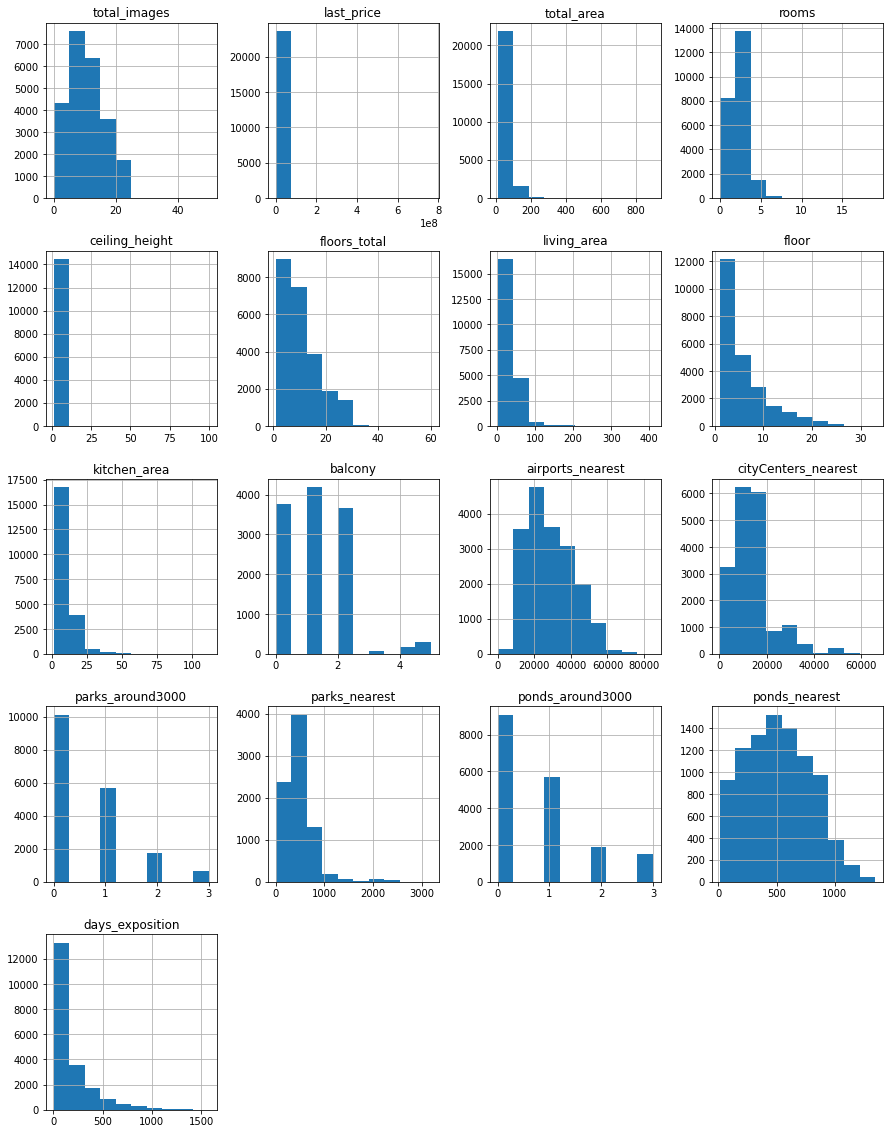

In [112]:
import pandas as pd
data = pd.read_csv('/datasets/real_estate_data.csv', sep = '\t')
data.hist(figsize = (15, 20))
print(data.head())

data.info()
print(data.describe())

*Большинство гистограмм выглядят как один высокий столбец, прижатый к левому краю, и длинная пустая ось X. Это происходит из-за единичных аномальных значений, которые растягивают шкалу*

**Изучив общие данные через info, можно придти к выводу, что:**
1. Масштабные проблемы с пропусками, особенно критические потери (is_apartment и parks_nearest и ponds_nearest)
2. Несоответствие типов данных (Dtype) - first_day_exposition и is_apartment и balcony и floors_total
parks_around3000 и ponds_around3000 и days_exposition

Памятка: Pandas автоматически переводит столбец в float64, если в нем появляются пропуски (NaN).

**Изучив общие данные через describe, можно придти к выводу, что:**

1. Аномалии и выбросы (min/max)
Высота потолков (ceiling_height): от 1 м до 100 м (при норме в 2.65 м).
Жилая площадь (living_area): минимум 2 кв. м.
Комнаты (rooms): от 0 (вероятно, студии/свободная планировка) до 19.
Цена (last_price): от 12 190 руб. (ошибка ввода или указана цена аренды).
До аэропорта (airports_nearest): от 0 метров.

2. Среднее против медианы
В столбцах last_price, total_area и days_exposition среднее арифметическое заметно превышает медиану (например, время продажи: 180 дней в среднем против 95 по медиане; площадь: 60 кв.м против 52).

Вывод: В данных присутствует «длинный хвост» из редких элитных или зависших в продаже объектов. Они сильно искажают картину, поэтому основной метрикой в анализе должна выступать медиана.


## Предобработка данных ⚙️

In [113]:
print(data.duplicated().sum())

0


In [114]:
print(data.isna().sum())

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64


In [115]:
### будем работать со столбцами last_price  balcony  is_apartment  first_day_exposition

# 1. столбец balcony должен иметь тип int и если есть пропуски, они должны быть заменены 0, очевидно, потому что балкона в квартире может не быть - случайный пропуск
data['balcony'] = data['balcony'].fillna(0).astype('int')

# 2. столбец is_apartment уже имеет нужный тип, поэтому только заменяем случайные пропуски
data['is_apartment'] = data['is_apartment'].fillna(False)

# 3. столбец last price не имеет пропусков, можем смело менять тип на int
data['last_price'] = data['last_price'].astype('int')

# 4. столбец first_day_exposition переведем в тип datatime
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format = '%Y-%m-%d')


# Было бы логично еще преобразовать тип в столбцах floors_total, parks_around3000, ponds_around3000 в int, но мы не можем этого сделать из-за пропущенных значений


- floors_total (всего этажей в доме): Здание физически не может состоять из 0 этажей. Пропуск означает лишь то, что продавец забыл указать этот параметр. Ноль здесь станет грубой ошибкой в данных.
------------------------------------------------------------------------------------------------------
- parks_around3000 и ponds_around3000 (парки и водоемы): Как мы выяснили ранее, пропуски в этих колонках — это результат сбоя картографической системы (она просто не подтянула данные для некоторых населенных пунктов). Если поставить 0, мы искусственно заявим: «В радиусе 3 км парков совершенно точно нет». На самом деле мы этого не знаем, и оставленный NaN честно сигнализирует об отсутствии информации.

In [116]:
data['floors_total'] = data['floors_total'].astype('Int64')
data['ponds_around3000'] = data['ponds_around3000'].astype('Int64')
data['ponds_around3000'] = data['ponds_around3000'].astype('Int64')

#Если написать название типа с заглавной буквы — 'Int64', то Pandas разрешит оставить пропуски и при этом сделает числа целыми!
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  int64         
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        14504 non-null  float64       
 6   floors_total          23613 non-null  Int64         
 7   living_area           21796 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  bool          
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          21421 non-null  float64       
 13  balcony         

**Заменим неявные дубликаты в столбце с названиями населенных пунктов**

In [117]:
print(data['locality_name'].dropna().sort_values().unique())
# dropna() нужен, чтобы сортировка не сломалась об NaN (+метод sort для столбца не сработает)

data = data.dropna(subset=['locality_name']).reset_index(drop=True) # удалим Nan

['Бокситогорск' 'Волосово' 'Волхов' 'Всеволожск' 'Выборг' 'Высоцк'
 'Гатчина' 'Зеленогорск' 'Ивангород' 'Каменногорск' 'Кингисепп' 'Кириши'
 'Кировск' 'Колпино' 'Коммунар' 'Красное Село' 'Кронштадт' 'Кудрово'
 'Лодейное Поле' 'Ломоносов' 'Луга' 'Любань' 'Мурино' 'Никольское'
 'Новая Ладога' 'Отрадное' 'Павловск' 'Петергоф' 'Пикалёво' 'Подпорожье'
 'Приморск' 'Приозерск' 'Пушкин' 'Санкт-Петербург' 'Светогорск'
 'Сертолово' 'Сестрорецк' 'Сланцы' 'Сосновый Бор' 'Сясьстрой' 'Тихвин'
 'Тосно' 'Шлиссельбург' 'городской поселок Большая Ижора'
 'городской поселок Янино-1' 'городской посёлок Будогощь'
 'городской посёлок Виллози' 'городской посёлок Лесогорский'
 'городской посёлок Мга' 'городской посёлок Назия'
 'городской посёлок Новоселье' 'городской посёлок Павлово'
 'городской посёлок Рощино' 'городской посёлок Свирьстрой'
 'городской посёлок Советский' 'городской посёлок Фёдоровское'
 'городской посёлок Янино-1' 'деревня Агалатово' 'деревня Аро'
 'деревня Батово' 'деревня Бегуницы' 'деревн

Мы имеем несколько проблем: 
- 1) Буква е/ё 
- 2) Путаница в типах поселков 
- 3) Отсутствие статуса (деревня Кудрово / Кудрово)

In [118]:
# 1) Буква е/ё
data['locality_name'] = data['locality_name'].str.replace('ё', 'е')
 

In [119]:
# 2) путаница в типах поселков
unique_poselki = data[data['locality_name'].str.contains('поселок')]['locality_name'].unique() # уникальные строчки, содержащие поселок


# Создаем пустое множество (set), чтобы статусы не повторялись
bad_poselok_types = set()

# Задача: получить список с уникальными приписками, т. е. поселок гор. типа, городской поселок и тд...
# Идея: разделить каждое значение, а далее выкинуть все слова с заглавной буквы (Название самих поселков)


for name in unique_poselki:
    words = name.split()
    type_words = []
    for word in words:
        if word.islower():
            type_words.append(word) # ['поселок'] ['поселок', 'городского'] ['поселок', 'городского', 'типа'].....
    full_type_words = ' '.join(type_words) # соединили
    if 'поселок' in full_type_words and full_type_words != 'поселок':
        bad_poselok_types.add(full_type_words) # используем add поскольку создали пустое мн. set()
        #bad_poselok_types = pd.Series(bad_poselok_types).unique() если бы создали списиок bad_poselok_types = []

print(bad_poselok_types)


data['locality_name_new'] = data['locality_name'] # поскольку таким методом мы уничтожим данные о элитных поселках и тд, лучше создать новый столбец

# теперь мы имеем финальный список с преписками, далее циклом устраиваем замену + проверку
for bad in bad_poselok_types:
    data['locality_name_new'] = data['locality_name_new'].str.replace(bad, 'поселок') 


{'поселок городского типа', 'поселок при железнодорожной станции', 'поселок станции', 'поселок 69-й километр', 'городской поселок', 'коттеджный поселок', 'поселок городского типа имени'}


In [120]:
#3) Отсутствие статуса (деревня Кудрово / Кудрово...)
# проблемы имеет Кудрово Мурино Любань
replace_dict = {
    'Кудрово': 'деревня Кудрово',
    'Мурино': 'поселок Мурино',
    'Любань': 'поселок Любань'
}

for old_name, new_name in replace_dict.items():
    data.loc[data['locality_name'] == old_name, 'locality_name'] = new_name 
    
    data.loc[data['locality_name_new'] == old_name, 'locality_name_new'] = new_name
    
    # присваиваем новое значеник по ключу только в столбце locality_name


In [121]:
print(data['locality_name_new'].unique())

data.info()

['Санкт-Петербург' 'поселок Шушары' 'поселок Янино-1' 'поселок Парголово'
 'поселок Мурино' 'Ломоносов' 'Сертолово' 'Петергоф' 'Пушкин'
 'деревня Кудрово' 'Коммунар' 'Колпино' 'поселок Красный Бор' 'Гатчина'
 'деревня Федоровское' 'Выборг' 'Кронштадт' 'Кировск'
 'деревня Новое Девяткино' 'поселок Металлострой' 'поселок Лебяжье'
 'поселок Сиверский' 'поселок Молодцово' 'поселок Кузьмоловский'
 'садовое товарищество Новая Ропша' 'Павловск' 'деревня Пикколово'
 'Всеволожск' 'Волхов' 'Кингисепп' 'Приозерск' 'Сестрорецк'
 'деревня Куттузи' 'поселок Аннино' 'поселок Ефимовский'
 'поселок Плодовое' 'деревня Заклинье' 'поселок Торковичи'
 'поселок Первомайское' 'Красное Село' 'поселок Понтонный' 'Сясьстрой'
 'деревня Старая' 'деревня Лесколово' 'поселок Новый Свет' 'Сланцы'
 'село Путилово' 'Ивангород' 'Шлиссельбург' 'Никольское' 'Зеленогорск'
 'Сосновый Бор' 'деревня Оржицы' 'деревня Кальтино' 'поселок Романовка'
 'поселок Бугры' 'поселок Рощино' 'Кириши' 'Луга' 'Волосово' 'Отрадное'
 'село П

<div class="alert alert-success">

**✔️ Комментарий ревьюера v2✔️**
   
   В целом, проведена качественная предобработка. Теория обработки пропусков хорошо изложена в статье: https://loginom.ru/blog/missing. Особенно хорошо описаны виды пропусков и их влияние на целесообразность и выбор способа заполнения.
Действительно, решая аналитические задачи, заполнение пропусков может быть необязательно, если объем достоверных данных достаточен для выявления закономерностей, а риск изменить распределение данных существеннен. Не зря в задании просят: "Заполните пропущенные значения там, где это возможно". При ответе на вопросы исследования можно взять только достоверно известные значения, а пропуски проигнорировать, если надежного способа их заполнить нет. 

</div>

## Добавлю в таблицу новые столбцы 📋

In [122]:
# прайс за кв-й метр
data['price_per_square_meter'] = (data['last_price']/data['total_area']).round(2)

# день недели объявления 
data['weekday_exposition'] = data['first_day_exposition'].dt.weekday

# месяц объявления 
data['month_exposition'] = data['first_day_exposition'].dt.month

# год публикации объявления 
data['year_exposition'] = data['first_day_exposition'].dt.year

# тип этажа квартиры (первый последний или другой) вместо грамоздкой функции, сделаем через loc()

data['type_floor'] = 'другой'
data.loc[data['floor'] == 1, 'type_floor'] = 'первый'
data.loc[data['floor'] == data['floors_total'], 'type_floor'] = 'последний'

# до центра расстояние в км
data['distance_center_km'] = (data['cityCenters_nearest'] / 1000).round() #вместо // поскольку он округлит до минимального, а не ближ-го




In [123]:
display(data.head())

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,locality_name_new,price_per_square_meter,weekday_exposition,month_exposition,year_exposition,type_floor,distance_center_km
0,20,13000000,108.0,2019-03-07,3,2.70,16,51.0,8,False,...,2,755.0,NaN,Санкт-Петербург,120370.37,3,3,2019,другой,16.0
1,7,3350000,40.4,2018-12-04,1,NaN,11,18.6,1,False,...,0,NaN,81.0,поселок Шушары,82920.79,1,12,2018,первый,19.0
2,10,5196000,56.0,2015-08-20,2,NaN,5,34.3,4,False,...,2,574.0,558.0,Санкт-Петербург,92785.71,3,8,2015,другой,14.0
3,0,64900000,159.0,2015-07-24,3,NaN,14,NaN,9,False,...,3,234.0,424.0,Санкт-Петербург,408176.10,4,7,2015,другой,7.0
4,2,10000000,100.0,2018-06-19,2,3.03,14,32.0,13,False,...,1,48.0,121.0,Санкт-Петербург,100000.00,1,6,2018,другой,8.0


## Исследовательский анализ данных 🔍

**1. Изучу выбранные параметры объектов и построю отдельные гистограммы для каждого из этих параметров**

In [124]:
# зафиксируем размер data для дальнейшего сравения с размером после фильтрации
shape_start = data.shape[0]
print(shape_start)


23650


<AxesSubplot:ylabel='Frequency'>

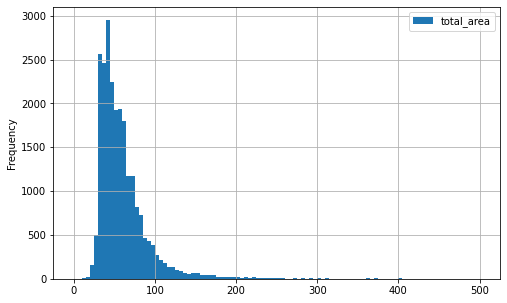

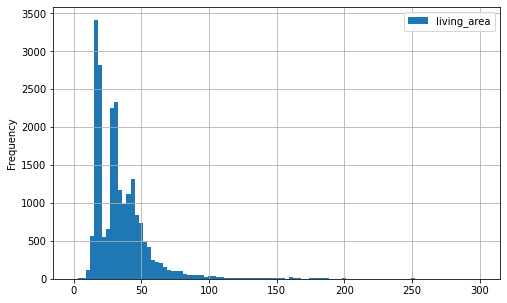

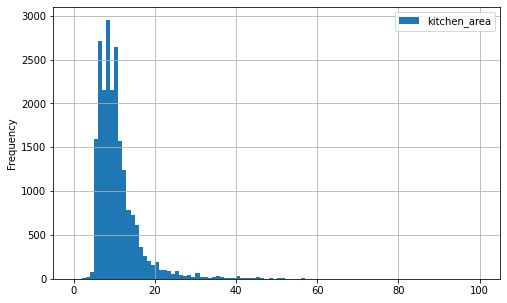

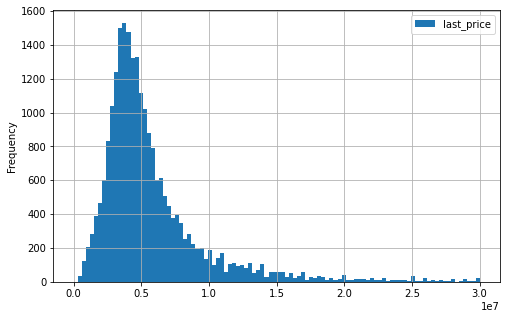

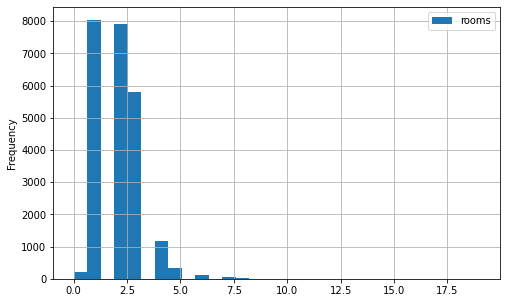

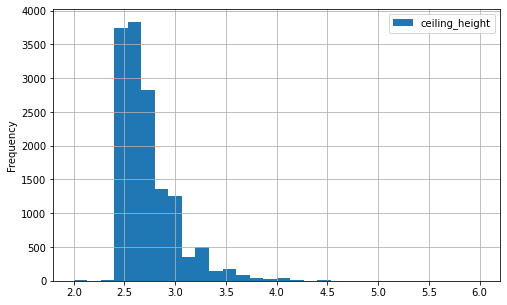

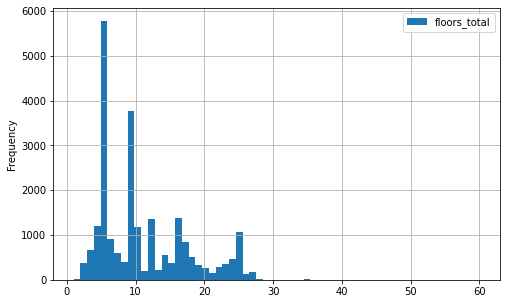

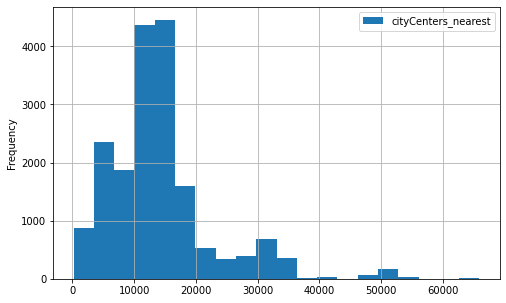

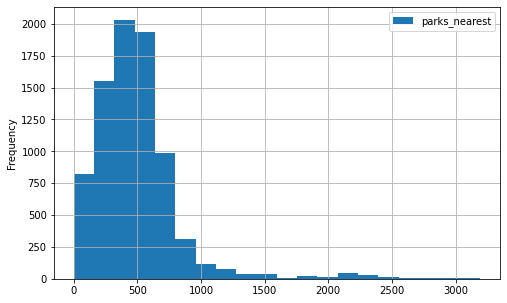

In [125]:
# Итог: range — Мы применяем его только там, где есть «бесконечные» правые хвосты, которые ломают визуализацию.
import matplotlib.pyplot as plt

#изучим общую площадь (отсечем дворцы плозадью 900 квадратов параметром range)
data.plot(y = 'total_area', kind = 'hist', bins = 100, grid = True, figsize= (8, 5), range = (0, 500))

#изучим жилую площадь 
data.plot(y = 'living_area', kind = 'hist', bins = 100, grid = True, figsize= (8, 5), range = (0, 300))

#изучим площадь кухни
data.plot(y = 'kitchen_area', kind = 'hist', bins = 100, grid = True, figsize= (8, 5), range = (0, 100))

#изучим цену, возьмем до 30_000_000, этого хватит для анализа
data.plot(y = 'last_price', kind = 'hist', bins = 100, grid = True, figsize= (8, 5), range = (0, 30000000))

#изучим число комнат
data.plot(y = 'rooms', kind = 'hist', bins=30, grid = True, figsize = (8, 5))

#изучим высоту потолков
data.plot(y = 'ceiling_height', kind = 'hist', bins=30, grid = True, figsize = (8, 5), range = (2, 6))

# изучим общее количество этажей в доме
data.plot(y = 'floors_total', kind = 'hist', bins = 60, grid = True, figsize = (8, 5))

# изучим расстояние до центра города в метрах
data.plot(y = 'cityCenters_nearest', kind = 'hist', bins = 20, grid = True, figsize = (8, 5))

# изучим расстояние до ближайшего парка
data.plot(y = 'parks_nearest', kind = 'hist', bins = 20, grid = True, figsize = (8, 5))

Проанализируем верхние графики:

Три вопроса, при анализе любой гистограммы:

* Где центр массы (мода)? (К примеру:Что покупают/продают чаще всего?)
* Какая форма у графика? 
* Есть ли странности? 
-----------------------------------------------------------------------------------
1. Площади и Деньги (total_area, kitchen_area, last_price):
Все три графика имеют классическое распределение Пуассона (скошенное вправо) - поскольку существует жесткий нижний предел (квартира не может быть 5 кв.м или стоить 100 рублей)
* Инсайты из графиков:
 total_area: Чаще всего на рынке встречаются квартиры от 30 до 50 кв.м. После 100 кв.м график резко стремится к нулю — это уже штучный, элитный товар.
 kitchen_area: Стандартная кухня — от 6 до 10 кв.м. Хвост тянется до 40 кв.м, но таких квартир ничтожно мало.
 last_price: Пик продаж приходится примерно на 3.5–4.5 млн. (На оси X подписано 1e7)
 
 --------------------------------------------------
2. Жилая площадь (living_area)
Странность: В отличие от общей площади, здесь мы видим два явных пика (бимодальное распределение). Один острый пик в районе 17–18 кв.м, а второй, чуть ниже, около 30 кв.м.
Мышление аналитика: Почему так? Потому что жилая площадь жестко привязана к количеству комнат. Первый пик — это стандартная жилая комната в «однушке». Второй пик — суммарная жилая площадь типовой «двушки»

------------------------------------------------------------
3. Целочисленные параметры (rooms, floors_total, ceiling_height)
* Инсайты из графиков:
 rooms: Огромные пики на 1 и 2 комнатах (бимодальное распределение). На начало оси X — там есть столбик с нулем комнат. В реальности квартир с 0 комнат не бывает. Это явная аномалия
 floors_total: График (мультимодальное распределение) похож на расческу. Ярко выражены пики на 5 и 9 этажах. Это исторический архитектурный след — массовая застройка хрущевками (5 этажей) и брежневками (9 этажей). Также видны всплески на современных стандартах (12, 16, 25 этажей).
 ceiling_height: График (унимодальное распределение). Массивный пик на 2.5–2.7 метрах (стандарт). Всё, что ниже 2.4 — скорее всего, ошибка в данных.
 
-----------------------------------------------------------------------
4. География (cityCenters_nearest, parks_nearest)

* Инсайты из графиков:

 cityCenters_nearest: Огромный пик на отметке 12 000 – 15 000 метров (12–15 км). Это типичный спальный пояс Санкт-Петербурга. Дальше идет спад и небольшие всплески на 30+ км — это города-спутники Ленинградской области (например, Пушкин или Колпино).
 parks_nearest: Пик на 400–500 метрах. Большинство парков находится в 5–7 минутах ходьбы от домов, выставленных на продажу.
    
Вывод:

Благодаря этим можно сделать вывод, что квартира на 5 этаже площадью 45 кв.м за 4 млн — это норма, а квартира с нулем комнат или потолками 2 метра — повод для чистки датасета.

In [126]:
columns_for_histograms = [
    'total_area',
    'living_area',
    'kitchen_area',
    'last_price',
    'rooms',
    'ceiling_height',
    'floors_total',
    'cityCenters_nearest',
    'parks_nearest'
]

for i in columns_for_histograms:
    display(data[i].describe())

count    23650.000000
mean        60.329069
std         35.661808
min         12.000000
25%         40.000000
50%         52.000000
75%         69.700000
max        900.000000
Name: total_area, dtype: float64

count    21752.000000
mean        34.448356
std         22.037664
min          2.000000
25%         18.600000
50%         30.000000
75%         42.300000
max        409.700000
Name: living_area, dtype: float64

count    21381.000000
mean        10.566403
std          5.901753
min          1.300000
25%          7.000000
50%          9.100000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

count    2.365000e+04
mean     6.541127e+06
std      1.089640e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.799000e+06
max      7.630000e+08
Name: last_price, dtype: float64

count    23650.000000
mean         2.070106
std          1.078620
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64

count    14490.000000
mean         2.771287
std          1.261593
min          1.000000
25%          2.520000
50%          2.650000
75%          2.800000
max        100.000000
Name: ceiling_height, dtype: float64

count    23565.000000
mean        10.675875
std          6.594823
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

count    18139.000000
mean     14197.860742
std       8606.830295
min        181.000000
25%       9241.000000
50%      13105.000000
75%      16293.000000
max      65968.000000
Name: cityCenters_nearest, dtype: float64

count    8064.000000
mean      490.830729
std       342.554386
min         1.000000
25%       288.000000
50%       454.500000
75%       612.000000
max      3190.000000
Name: parks_nearest, dtype: float64

<AxesSubplot:>

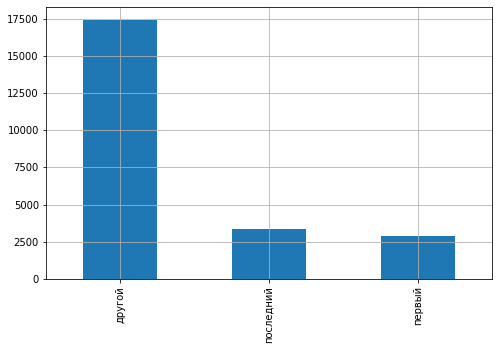

In [127]:
#изучим тип этажа квартиры (используем столбчатую, потому что hist не может построить без числовых значений)
data['type_floor'].value_counts().plot(kind = 'bar', grid = True, figsize = (8, 5))

**В ходе анализа выявлены следующие ошибки в данных (аномалии):**

- Физически невозможные габариты: жилая площадь от 2 м² и кухни от 1.3 м².
- Аномалии в высоте потолков: невозможные значения (1 м, 60 м), а также опечатки ввода (25-36 м), которые, скорее всего, подразумевают 2.5-3.6 м без десятичной точки.
- Ошибка в стоимости: минимальная цена объекта составляет 12 тыс. рублей.
- Структурная аномалия: наличие квартир с 0 комнат (требует проверки на принадлежность к студиям).

Экстремальные максимумы (19 комнат, кухни по 112 м²) являются следствием специфики рынка Санкт-Петербурга (элитная недвижимость и большие коммунальные квартиры), а не ошибками данных. (дополнительно проверим и убедимся)


**Изучим квартиры с аномальными значениями**

In [128]:

print(data.query('living_area == 2'))
print()
print(data.loc[data['living_area'] == 2, 'kitchen_area'])
print()
#для строки с индексом 13892: total_area = 52 и kitchen_area = 9 => можно сделать вывод что сработал человеческий фактор им ввели вместо living_area = 20м, 2м) 
#для строки с индексом 21714: нет информации по кухке, значит мы не можем заменить значения living_area   
# --------------------

data.loc[13892, 'living_area'] = 20
#----------------------------------
# поскольку у квартиры с индексом 21714 много пропущенных данных, можно удалить ее из датафрейма
data = data.query('living_area != 2').copy()
print('------------------------------------')
print(data.shape[0])
print('------------------------------------')

# вернемся к срезу данных после устранения всех аномалий
data.query('living_area < 10')['living_area'].value_counts().sort_index()

       total_images  last_price  total_area first_day_exposition  rooms  \
13892            20     6350000        52.0           2018-02-06      2   
21714             0     2330000        23.0           2018-01-01      0   

       ceiling_height  floors_total  living_area  floor  is_apartment  ...  \
13892             3.0             6          2.0      2         False  ...   
21714             NaN            24          2.0     22         False  ...   

       ponds_around3000  ponds_nearest  days_exposition  locality_name_new  \
13892                 1         1012.0             91.0    Санкт-Петербург   
21714              <NA>            NaN             66.0     поселок Мурино   

      price_per_square_meter  weekday_exposition  month_exposition  \
13892              122115.38                   1                 2   
21714              101304.35                   0                 1   

       year_exposition  type_floor  distance_center_km  
13892             2018      другой  

3.0    2
5.0    1
5.4    1
6.0    1
6.5    1
8.0    2
8.3    1
8.4    1
8.5    1
8.9    1
9.0    9
9.1    1
9.8    1
Name: living_area, dtype: int64

In [129]:
print(data.query('kitchen_area == 1.3'))

# судя по данным всех площадей нельзя сделать вывод, что вместо 13 написали 1.3 - не трогаем

       total_images  last_price  total_area first_day_exposition  rooms  \
20180             7     4250000        28.5           2019-05-01      1   

       ceiling_height  floors_total  living_area  floor  is_apartment  ...  \
20180             2.8            14         19.5     10         False  ...   

       ponds_around3000  ponds_nearest  days_exposition  locality_name_new  \
20180                 0            NaN              NaN    Санкт-Петербург   

      price_per_square_meter  weekday_exposition  month_exposition  \
20180              149122.81                   2                 5   

       year_exposition  type_floor  distance_center_km  
20180             2019      другой                13.0  

[1 rows x 29 columns]


In [130]:
print(data.query('last_price == 12190'))
print()
#Выдвенем гипотезу: ошибочно забыли 3 нуля
#Провери гипотезу: сравним ценовой диапозон квартир с такой же площадью и удаленностью от центра

print(data.query('95 < total_area < 115 and 7 < distance_center_km < 10')['last_price'].median())
print()
#гипотеза подтвердилась .median():  last_price = 1.310000e+07

data.loc[8778, 'last_price'] = 12190000

#пересчитаем среднюю стоимость за кв метр

data.loc[8778, 'price_per_square_meter'] = data.loc[8778, 'last_price'] / data.loc[8778, 'total_area']

print(data.shape[0])

      total_images  last_price  total_area first_day_exposition  rooms  \
8778             7       12190       109.0           2019-03-20      2   

      ceiling_height  floors_total  living_area  floor  is_apartment  ...  \
8778            2.75            25         32.0     25         False  ...   

      ponds_around3000  ponds_nearest  days_exposition  locality_name_new  \
8778                 0            NaN              8.0    Санкт-Петербург   

     price_per_square_meter  weekday_exposition  month_exposition  \
8778                 111.83                   2                 3   

      year_exposition  type_floor  distance_center_km  
8778             2019   последний                 9.0  

[1 rows x 29 columns]

13100000.0

23649


In [131]:
#второй столбец означает высоту потолка, можно заметить две аномалии: 1) невозможные значения <2 и 100м | 2) значения с пропущенной точкой от 20 до 32
print('До')
print(data.query('ceiling_height < 2 or ceiling_height > 5')['ceiling_height'].sort_values())
print('''
После
''')
# Отвязываем датафрейм от предыдущих срезов для защиты от SettingWithCopyWarning
data = data.copy()

# 1. Исправляем опечатки (там, где забыли поставить точку: 25 -> 2.5, 32 -> 3.2)
# Диапазон от 20 метров логично превратить в 2.0 - 5.0 метров
data.loc[data['ceiling_height'] >= 20, 'ceiling_height'] /= 10 # = нужно чтобы перезаписать строки

# 2. Убираем физически невозможные значения 
# Обязательно используем isna(), чтобы сберечь строки с пропусками для следующего шага
data = data.query('2 <= ceiling_height <= 6 or ceiling_height.isna()').copy()

# 3. Рассчитываем эталонную медиану и заполняем пропуски
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())

print(data['ceiling_height'].describe())
print(data.shape[0])


До
22544      1.00
5702       1.20
16904      1.75
464        5.20
12609      5.30
1026       5.30
7565       5.50
1387       5.60
21186      5.80
20227      6.00
3470       8.00
15717      8.00
17412      8.00
5853       8.30
22264     10.30
15036     14.00
17466     20.00
20469     22.60
5068      24.00
18512     25.00
355       25.00
11266     25.00
4636      25.00
9363      25.00
6236      25.00
14357     25.00
5660      26.00
20440     27.00
21780     27.00
4868      27.00
22890     27.00
5797      27.00
17825     27.00
10755     27.00
5238      27.00
21334     27.50
22291     32.00
3144      32.00
22822    100.00
Name: ceiling_height, dtype: float64

После

count    23639.000000
mean         2.696779
std          0.221099
min          2.000000
25%          2.600000
50%          2.650000
75%          2.700000
max          6.000000
Name: ceiling_height, dtype: float64
23639


- Можно было бы и сначала заполнить пропуски медианой, поскольку она устойчива к аномалиям. Но если бы аномалий было бы оч много, например 30%, это бы исказило медиану

**Сначала делаем данные достоверными (исправляем и удаляем мусор), а только затем вычисляем метрику для заполнения пустот.**

In [132]:
print(data['rooms'].describe())


count    23639.000000
mean         2.070392
std          1.078658
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64


In [133]:
print(data.query('rooms == 0 ').head())
# по метражу стоимости все ок - это студии
print('''
''')
print(data.query('rooms == 19 ').head())
# по метражу стоимости все ок - это огромный пентхаус

     total_images  last_price  total_area first_day_exposition  rooms  \
144             1     2450000       27.00           2017-03-30      0   
349             4     2320000       25.00           2017-09-27      0   
440             8     2480000       27.11           2018-03-12      0   
508             0     3375000       34.40           2017-03-28      0   
608             2     1850000       25.00           2019-02-20      0   

     ceiling_height  floors_total  living_area  floor  is_apartment  ...  \
144            2.65            24        15.50      2         False  ...   
349            2.65            14        17.00      1         False  ...   
440            2.65            17        24.75      4         False  ...   
508            2.65            26        24.30     19         False  ...   
608            2.65            10          NaN      7         False  ...   

     ponds_around3000  ponds_nearest  days_exposition  locality_name_new  \
144              <NA>       

In [134]:
for i in columns_for_histograms:
    display(data[i].describe())


shape_end = data.shape[0]
print(data.shape[0])
print(shape_end / shape_start)



count    23639.000000
mean        60.336702
std         35.667210
min         12.000000
25%         40.000000
50%         52.000000
75%         69.745000
max        900.000000
Name: total_area, dtype: float64

count    21741.000000
mean        34.455307
std         22.039387
min          3.000000
25%         18.600000
50%         30.000000
75%         42.300000
max        409.700000
Name: living_area, dtype: float64

count    21373.000000
mean        10.567212
std          5.902624
min          1.300000
25%          7.000000
50%          9.100000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

count    2.363900e+04
mean     6.542239e+06
std      1.089862e+07
min      4.300000e+05
25%      3.400000e+06
50%      4.650000e+06
75%      6.799500e+06
max      7.630000e+08
Name: last_price, dtype: float64

count    23639.000000
mean         2.070392
std          1.078658
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64

count    23639.000000
mean         2.696779
std          0.221099
min          2.000000
25%          2.600000
50%          2.650000
75%          2.700000
max          6.000000
Name: ceiling_height, dtype: float64

count    23554.000000
mean        10.674408
std          6.592692
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

count    18131.000000
mean     14197.597816
std       8607.788769
min        181.000000
25%       9241.000000
50%      13105.000000
75%      16293.000000
max      65968.000000
Name: cityCenters_nearest, dtype: float64

count    8060.000000
mean      490.866005
std       342.609080
min         1.000000
25%       288.000000
50%       455.000000
75%       612.000000
max      3190.000000
Name: parks_nearest, dtype: float64

23639
0.9995348837209302


<div class="alert alert-block alert-info">
теперь получилось, значение больше 90%
</div>

*После детального анализа аномалий очевидные ошибки ввода были скорректированы, а строки с необъяснимыми выбросами — удалены.*

*Проведена обработка выбросов: исправлены вероятные опечатки, записи с неясной природой аномалий исключены из датасета.*

**2. Изучу, как быстро продавались квартиры (столбец days_exposition). (Этот параметр показывает, сколько дней было размещено каждое объявление). 
Построю гистограмму.
Посчитаю среднее и медиану.**

count    20459.000000
mean       180.755071
std        219.803187
min          1.000000
25%         45.000000
50%         95.000000
75%        231.000000
max       1580.000000
Name: days_exposition, dtype: float64


<AxesSubplot:>

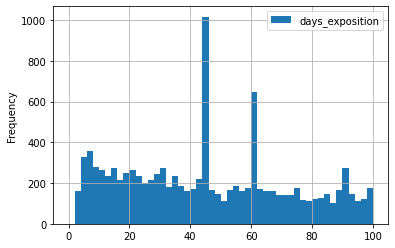

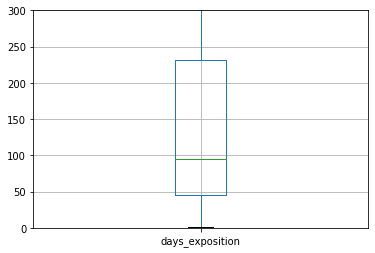

In [135]:
print(data['days_exposition'].describe())
data.plot(y='days_exposition', kind='hist',bins=50, grid=True, range=(0,100))
#по графику видим  пики через 45 60 90 дней
#получили медиану 95 и среднее 185 
#<q1=45: сделки до 45 дней считаются быстрыми | q1-q3: обычная скорость около 95 дней | >231 дней долгие

data.plot(y='days_exposition', kind='box', grid=True, ylim=(0, 300))

**3.Определю факторы, которые больше всего влияют на общую (полную) стоимость объекта.
Зависит ли цена от:
общей площади;
жилой площади;
площади кухни;
количества комнат;
этажа;
даты размещения.
И построю графики, которые покажут зависимость цены от указанных выше параметров.**

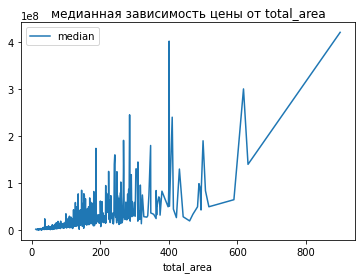

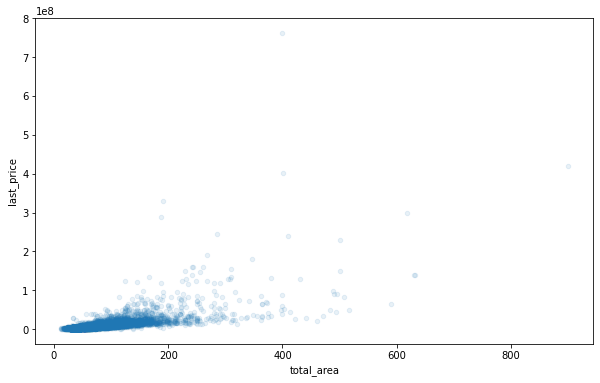

Коэффицент корелляции total_area и цены = 0.6538585123163233

------------------------------------------------------------------------------------------


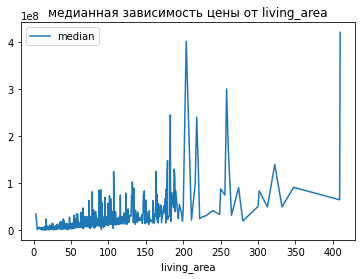

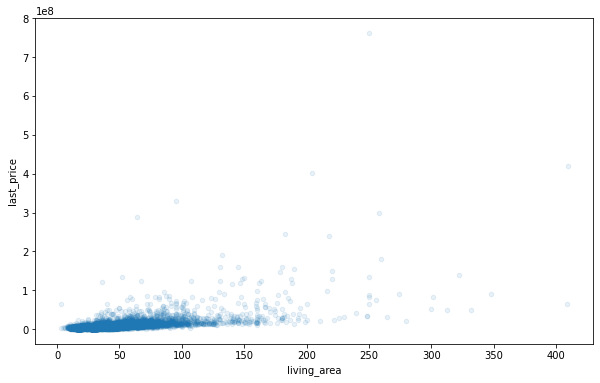

Коэффицент корелляции living_area и цены = 0.5665940546251026

------------------------------------------------------------------------------------------


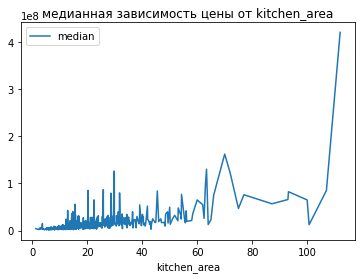

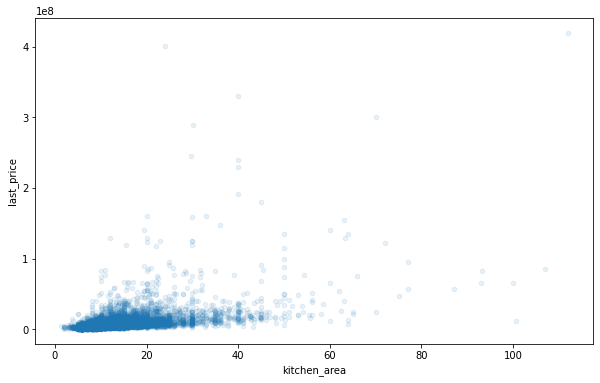

Коэффицент корелляции kitchen_area и цены = 0.520520646225527

------------------------------------------------------------------------------------------


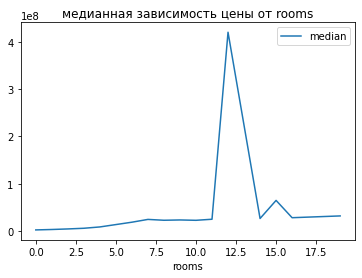

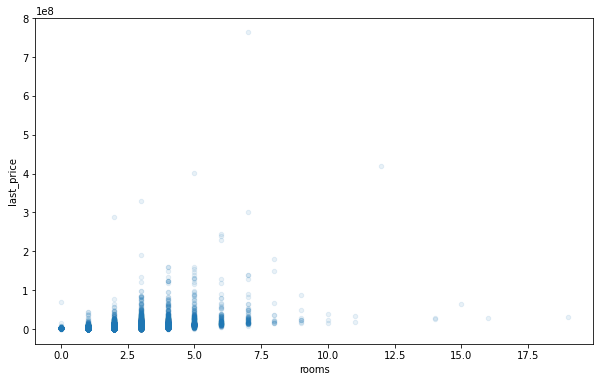

Коэффицент корелляции rooms и цены = 0.3634651038080351

------------------------------------------------------------------------------------------


In [136]:
list_analysis = ['total_area', 'living_area', 'kitchen_area', 'rooms']

for i in list_analysis:
#подготовим данные для графиков
    Total_corr = data.pivot_table(index=i, values='last_price', aggfunc=['mean', 'median', 'count'])
    Total_corr.columns = ['mean', 'median', 'count']
#строим графики:
    Total_corr.plot(y='median', title = f'медианная зависимость цены от {i}') #если не указывать kind='', то по умолчанию line
    plt.show()

    data.plot(kind='scatter', x=i, y='last_price', alpha=0.1, figsize=(10, 6))
    plt.show()
#проведем корреляционных анализ по исходной таблице (сводная таблица с медианными значениями искажает исходные данные)
    corr_value = data[i].corr(data['last_price'])
    
    print(f'Коэффицент корелляции {i} и цены = {corr_value}')
    print()
    print('-'*90) 

**микро-вывод 1:**
- Сильная корреляционная связь (0.65): Общая площадь выступает ключевым фактором, определяющим стоимость объекта недвижимости.

- Умеренная корреляционная связь (0.56 и 0.52): Жилая площадь и площадь кухни оказывают значимое влияние на ценообразование, однако данные метрики являются вторичными по отношению к совокупному метражу.

- Слабая корреляционная связь (0.36): Количество комнат демонстрирует наименьшее влияние на итоговую цену. Данный показатель не является определяющим, поскольку рыночная оценка базируется преимущественно на фактической площади объекта, а не на его внутреннем зонировании (крупногабаритная недвижимость с открытой планировкой может превосходить по стоимости многокомнатные объекты меньшего метража).

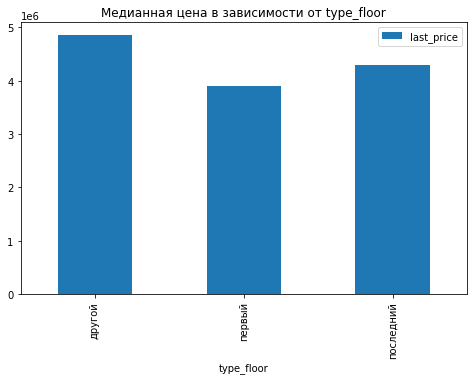

------------------------------------------------------------------------------------------


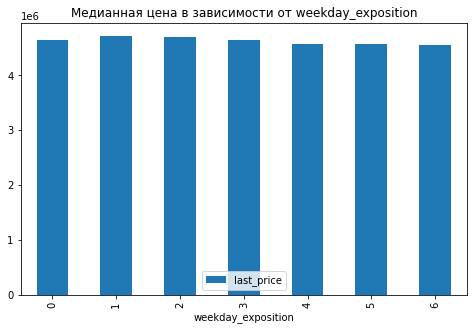

------------------------------------------------------------------------------------------


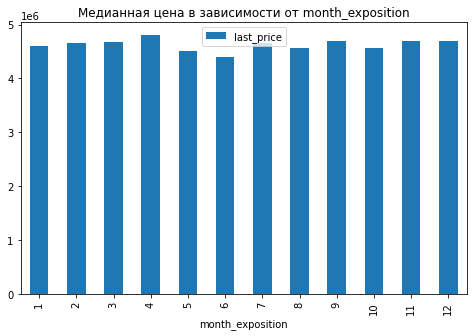

------------------------------------------------------------------------------------------


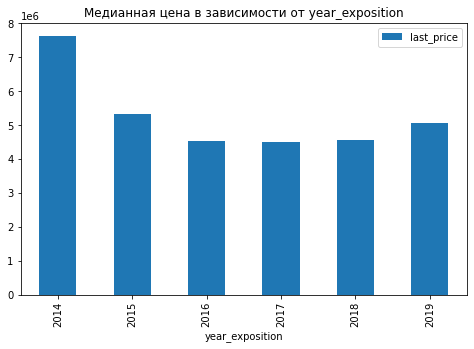

------------------------------------------------------------------------------------------


,mean,median,count
year_exposition,,,
2017,6.586904e+06,4500000,8182
2016,6.829860e+06,4540000,2764
2018,5.952185e+06,4550000,8506
2019,6.786618e+06,5050000,2879
2015,8.595494e+06,5337000,1172
2014,1.204660e+07,7640000,136


In [137]:
list_categorical = ['type_floor', 'weekday_exposition', 'month_exposition', 'year_exposition']

for i in list_categorical:
    # Собираем медианную цену
    pivot_corr = data.pivot_table(index=i, values='last_price', aggfunc='median')
    
    # Строим график (для категорий отлично подходит bar - столбчатая диаграмма)
    pivot_corr.plot(kind='bar', y='last_price', title=f'Медианная цена в зависимости от {i}', figsize=(8, 5))
    plt.show()
    print('-'*90)

x = data.pivot_table(index='year_exposition', values='last_price', aggfunc= ['mean', 'median', 'count'])
x.columns = ['mean', 'median', 'count']
x.sort_values(by='median')

**Микро-вывод 2:**

- График подтверждает золотое правило рынка о том, что первый и последний этаж в среднем дешевле "других" этажей. Также видно, что на минимальную медианную цену имеет первый этаж
- день недели публикации слабо влияет на показатели цены
- по месяцам публикации можно сделать вывод, что в апреле цена достигает своего пика, а в июне минимальна
- График год выставления объявления показывает, что цена нахродится в пике в 2014 году, а далее убывает до 2018, и чуть растет в последний год

In [138]:
# отработаем комментарий
area_by_year = data.groupby('year_exposition')['total_area'].median() # как пример вместо сводных таблиц
print(area_by_year)

year_exposition
2014    76.18
2015    60.00
2016    53.01
2017    52.00
2018    50.50
2019    52.00
Name: total_area, dtype: float64


**Микро-вывод 3:**

- Анализ подтвердил, что на снижение медианной цены в период с 2014 года влияет выход на рынок большого числа малогабаритных квартир.

**Общий вывод:**
Анализ зависимостей выбранных показателей от цены выявил:
- Самая высокая зависимость от цены оказалась у общей площади (corr = 0.65). Это также и подтвердил анализ года выставления объявления, где уменьшение площади стало основной причиной падения медианной цены.
- Умеренное влияние имеют жилая площадь и площадь кухни, а также тип этажа (квартиры на первом этаже стабильно стоят дешевле остальных). Из временных факторов легкую сезонность показывает только месяц публикации (пик цен в апреле).
- Самая низкая зависимость от количества комнат (corr = 0.36), а также дня недели выставления объявления

**4. Посчитаю среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений — построю сводную таблицу с количеством объявлений и средней ценой квадратного метра для этих населенных пунктов.**

In [139]:
# Определяем индексы топ-10 населенных пунктов по количеству объявлений
top_10_localities = data['locality_name_new'].value_counts().head(10)

# Фильтруем исходный датафрейм
top_10_data = data.query('locality_name_new in @top_10_localities.index')

# Строим сводную таблицу (вычисления происходят только для 10 локаций — это очень быстро)
pivot_top_10 = top_10_data.pivot_table(
    index='locality_name_new', 
    values='price_per_square_meter', 
    aggfunc=['count', 'mean']
)

pivot_top_10.columns = ['Количество объявлений', 'Средняя цена за кв.м']



# ДЛЯ КРАСИВОГО ВЫВОДА:
pivot_top_10 = pivot_top_10.sort_values(by='Средняя цена за кв.м', ascending=False)
print("=== Сводная таблица Топ-10 ===")
print(pivot_top_10)
print("="*70)

# ПРОГРАММНЫЙ ПОИСК ЭКСТРЕМУМОВ
# idxmax() возвращает название города (индекс), где значение в столбце максимально
max_city = pivot_top_10['Средняя цена за кв.м'].idxmax()
max_price = pivot_top_10['Средняя цена за кв.м'].max()

# idxmin() возвращает название города (индекс), где значение в столбце минимально
min_city = pivot_top_10['Средняя цена за кв.м'].idxmin()
min_price = pivot_top_10['Средняя цена за кв.м'].min()

print(f"Самая высокая стоимость квадратного метра: {max_city} — {max_price:.0f} руб.")
print(f"Самая низкая стоимость квадратного метра: {min_city} — {min_price:.0f} руб.")

=== Сводная таблица Топ-10 ===
                   Количество объявлений  Средняя цена за кв.м
locality_name_new                                             
Санкт-Петербург                    15714         114828.509173
Пушкин                               369         103125.819377
деревня Кудрово                      472          95324.930508
поселок Парголово                    327          90175.913089
поселок Мурино                       589          86061.676978
поселок Шушары                       440          78677.364318
Колпино                              338          75424.579112
Гатчина                              307          68746.146515
Всеволожск                           398          68654.473970
Выборг                               237          58141.909325
Самая высокая стоимость квадратного метра: Санкт-Петербург — 114829 руб.
Самая низкая стоимость квадратного метра: Выборг — 58142 руб.


**5. Теперь выделю квартиры в Санкт-Петербурге с помощью столбца locality_name и вычислите их среднюю стоимость на разном удалении от центра. Учитывайте каждый километр расстояния: узнайте среднюю цену квартир в одном километре от центра, в двух и так далее. Опишу, как стоимость объектов зависит от расстояния до центра города — постройте график изменения средней цены для каждого километра от центра Петербурга.**

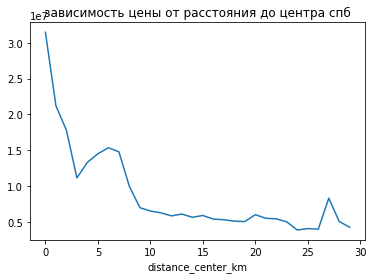

In [140]:
data_spb = data.query('locality_name_new == "Санкт-Петербург"')
data_spb_mean = data_spb.groupby('distance_center_km')['last_price'].mean()

data_spb_mean.plot(y = 'mean', title = 'зависимость цены от расстояния до центра спб')
plt.show()

Анализ графика показывает четкую обратную зависимость: по мере удаления от исторического центра средняя стоимость квартир снижается. Три интересных момента:
- первый локальный пик от 4 км до 7 км - элитные районы спб 
- второй локальный пик 27км - курортная зона с элитной недвижимостью
- после 7-8км резкий спад и далее равномерное падение (граница центральной части города)

In [141]:
#некоторые значения для вывода
total_area_1 = data.query('total_area > 12 and total_area < 30')
print(total_area_1['last_price'].mean())

total_area_2 = data.query('total_area > 29 and total_area < 60')
print(total_area_2['last_price'].mean())

total_area_3 = data.query('total_area > 59 and total_area < 100')
print(total_area_3['last_price'].mean())

total_area_4 = data.query('total_area > 99 and total_area < 200')
print(total_area_4['last_price'].mean())

total_area_5 = data.query('total_area > 199')
print(total_area_5['last_price'].mean())

living_area_1 = data.query('living_area > 1 and living_area < 30')
print(living_area_1['last_price'].mean())

living_area_2 = data.query('living_area > 29 and living_area < 60')
print(living_area_2['last_price'].mean())

living_area_3 = data.query('living_area > 59 and living_area < 100')
print(living_area_3['last_price'].mean())

living_area_4 = data.query('living_area > 99 and living_area < 200')
print(living_area_4['last_price'].mean())

living_area_5 = data.query('living_area > 199')
print(living_area_5['last_price'].mean())

print('-'* 70)

floor_category_first = data.query('type_floor == "первый"')
print(floor_category_first['last_price'].median())

floor_category_last = data.query('type_floor == "последний"')
print(floor_category_last['last_price'].median())

floor_category_another = data.query('type_floor != "первый" and type_floor != "последний"')
print(floor_category_another['last_price'].median())

print('-'* 70)

center_nears_1 = data.query('distance_center_km > 0 and distance_center_km <= 7')
print(center_nears_1['last_price'].mean())

center_nears_2 = data.query('distance_center_km > 7 and distance_center_km < 40')
print(center_nears_2['last_price'].mean())

center_nears_3 = data.query('distance_center_km > 41 and distance_center_km < 43')
print(center_nears_3['last_price'].mean())

center_nears_4 = data.query('distance_center_km > 53 and distance_center_km < 56')
print(center_nears_4['last_price'].mean())

print('-'* 70)

kitchen_area_1 = data.query('kitchen_area > 0 and kitchen_area < 9')
print(kitchen_area_1['last_price'].mean())

kitchen_area_2 = data.query('kitchen_area > 8 and kitchen_area < 12')
print(kitchen_area_2['last_price'].mean())

kitchen_area_3 = data.query('kitchen_area > 11 and kitchen_area < 15')
print(kitchen_area_3['last_price'].mean())

print('-'* 70)

rooms_0 = data.query('rooms == 0')
print(rooms_0['last_price'].mean())

rooms_1 = data.query('rooms == 1')
print(rooms_1['last_price'].mean())

rooms_2 = data.query('rooms == 2')
print(rooms_2['last_price'].mean())

rooms_3 = data.query('rooms == 3')
print(rooms_3['last_price'].mean())

2687945.1103047896
4014455.678304415
7357389.452819576
18401091.428487346
59091288.95689655
3904834.1638477803
6546927.342011129
16047683.32179676
33861286.205882356
124580545.45454545
----------------------------------------------------------------------
3900000.0
4300000.0
4850000.0
----------------------------------------------------------------------
14767757.338765008
5842106.775842776
3058333.3333333335
7182100.0
----------------------------------------------------------------------
4054824.0943971407
5328514.242808386
7650696.112967158
----------------------------------------------------------------------
3342865.56122449
3832550.533557465
5592659.145707071
8182243.303485163


##  Общий вывод 🔚

**Проведенный анализ данных позволил определить ключевые факторы ценообразования и разделить их по степени влияния на итоговую стоимость:**

**СИЛЬНО ВЛИЯЮТ**

- Общая площадь: Наблюдается строгая прямая зависимость — чем больше площадь, тем выше цена. Квартиры от 12 до 30 м² стоят в среднем 2.7 млн руб., от 30 до 60 м² — 4.0 млн руб., от 60 до 100 м² — 7.4 млн руб., от 100 до 200 м² — 18.4 млн руб., а объекты свыше 200 м² — 59.1 млн руб.

- Жилая площадь: Сохраняется аналогичный тренд. Объекты до 30 м² стоят в среднем 3.9 млн руб., от 30 до 60 м² — 6.5 млн руб., от 60 до 100 м² — 16.0 млн руб., от 100 до 200 м² — 33.9 млн руб., свыше 200 м² — более 124.6 млн руб.

- Тип этажа: Квартиры на первом этаже стабильно оцениваются рынком дешевле всего (медианная цена — 3.9 млн руб.). Квартиры на последнем этаже стоят дороже (4.3 млн руб.), но максимальную стоимость имеют объекты на всех промежуточных этажах (4.85 млн руб.).

- Расстояние до центра: Выявлена четкая обратная зависимость. В радиусе до 7 км средняя цена максимальна (14.8 млн руб.). При удалении от 8 до 40 км цена падает до 5.8 млн руб. В зоне 41–43 км зафиксирован глубокий спад до 3.1 млн руб., однако на удалении 53–56 км наблюдается локальный всплеск (до 7.2 млн руб.), что характерно для загородных элитных направлений.

**УМЕРЕННО ВЛИЯЮТ**

- Количество комнат: Цена предсказуемо растет вместе с числом комнат. Студии (0 комнат) стоят в среднем 3.3 млн руб., однокомнатные квартиры — 3.8 млн руб., двухкомнатные — 5.6 млн руб., трехкомнатные — 8.2 млн руб.

- Площадь кухни: Оказывает влияние на стоимость, но вторично по отношению к общим габаритам. При площади кухни до 9 м² средняя цена объекта составляет 4.1 млн руб., от 9 до 12 м² — 5.3 млн руб., от 12 до 15 м² — 7.7 млн руб.

**ПРАКТИЧЕСКИ НЕ ВЛИЯЮТ**

- Временные факторы: День недели, месяц и год публикации объявления не показывают прямой зависимости с ценой (показатели стоимости практически идентичны для разных периодов публикации).